<a href="https://colab.research.google.com/github/sevenjunebaby/Classification/blob/main/Reddit_Post_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install praw scikit-learn pandas

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 189.3/189.3 kB 5.7 MB/s eta 0:00:00


# 1. Direct Reddit API credentials




In [2]:
import praw
reddit = praw.Reddit(
    client_id="your client id",
    client_secret="your secret key",
    user_agent="reddit_script"
)

# 2. Collect subreddit posts

In [3]:
import pandas as pd

subreddit_name = "movies"
limit_posts = 100

posts = []
subreddit = reddit.subreddit(subreddit_name)

print(f"Collecting {limit_posts} hot posts from r/{subreddit_name}...")

for post in subreddit.hot(limit=limit_posts):
    posts.append({
        "title": post.title,
        "author": str(post.author),
        "upvotes": post.score,
        "num_comments": post.num_comments,
    })

df = pd.DataFrame(posts)

It is strongly recommended to use Async PRAW: https://asyncpraw.readthedocs.io.
See https://praw.readthedocs.io/en/latest/getting_started/multiple_instances.html#discord-bots-and-asynchronous-environments for more info.



# 3. Create labels

In [4]:
df["label"] = "Other"
df.loc[:10, "label"] = [
    "Action", "Drama", "Comedy", "Other", "Horror",
    "Action", "Drama", "Other", "Comedy", "Action", "Drama"
]
# -------------------------------------------------------------
# *** MANUAL LABELING EXPANSION ***
df.loc[11:25, "label"] = "Action"
df.loc[26:40, "label"] = "Drama"
df.loc[41:45, "label"] = "Comedy"
# -------------------------------------------------------------

df["text"] = df["title"].astype(str)
min_samples = 3
label_counts = df["label"].value_counts()
valid_labels = label_counts[label_counts >= min_samples].index.tolist()
df_filtered = df[df["label"].isin(valid_labels)].copy()
print("Original label counts (AFTER EXPANSION):")
print(df["label"].value_counts())

Original label counts (AFTER EXPANSION):
label
Other     56
Action    18
Drama     18
Comedy     7
Horror     1
Name: count, dtype: int64


# 4. Data Cleaning

In [5]:
import pandas as pd
import re
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import SGDClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

def clean_text(text):
    """Removes special characters, links, and numbers, then converts to lowercase."""
    text = str(text)
    text = re.sub(r'http\S+', '', text)
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    return text.lower().strip()
df_filtered["cleaned_text"] = df_filtered["text"].apply(clean_text)

# 5: Model Training and Evaluation (Validation Logic)

In [6]:
model = Pipeline([
    ("tfidf", TfidfVectorizer(
        ngram_range=(1, 2),
        max_df=0.9,
        min_df=2,
        stop_words="english"
    )),
    ("clf", SGDClassifier(
        loss="log_loss",
        penalty="l2",
        alpha=1e-4,
        max_iter=1000,
        random_state=42
    ))
])
X = df_filtered["cleaned_text"]
y = df_filtered["label"]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)



=== FINAL CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

      Action       0.00      0.00      0.00         5
      Comedy       0.00      0.00      0.00         2
       Drama       0.17      0.25      0.20         4
       Other       0.65      0.79      0.71        14

    accuracy                           0.48        25
   macro avg       0.20      0.26      0.23        25
weighted avg       0.39      0.48      0.43        25



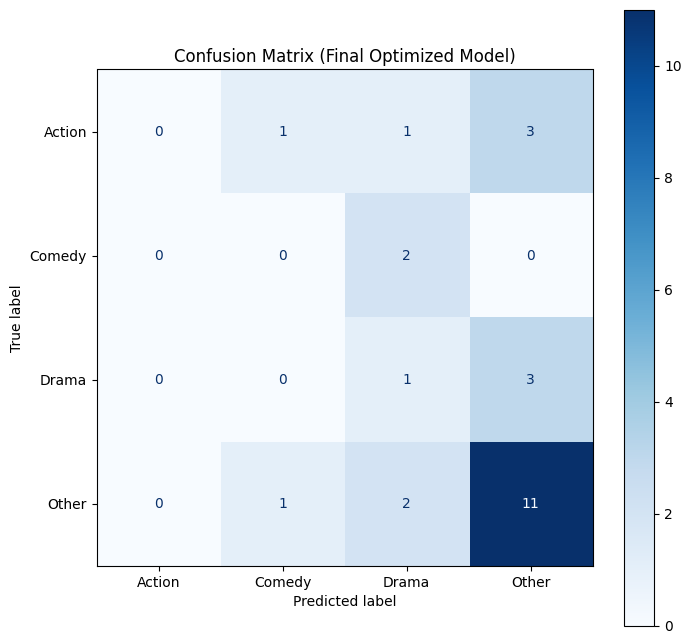

In [7]:
# Fit the model to the training data
model.fit(X_train, y_train)

# Predict and evaluate
y_pred = model.predict(X_test)

print("\n=== FINAL CLASSIFICATION REPORT ===")
print(classification_report(y_test, y_pred, zero_division=0))

# Plot Confusion Matrix
cm = confusion_matrix(y_test, y_pred, labels=model.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_)

fig, ax = plt.subplots(figsize=(8, 8))
disp.plot(cmap=plt.cm.Blues, ax=ax)
plt.title("Confusion Matrix (Final Optimized Model)")
plt.show()
df["predicted_label"] = model.predict(df["text"].apply(clean_text))